# Taller 4: Detección de contornos

**Profesor**: PhD Juan Pablo Reyes

**Autores**: Estefanía Laverde, Harvy Benitez.

**Nota:** Se declara el uso de ChatGPT en la elaboración de la versión final de este Taller. Siguiendo la recomendación del profesor, se utilizó como base el código provisto en el enlace del Taller 3, dado que este facilita implementaciones específicas que resultan innecesariamente complejas cuando se generan desde cero con una herramienta de IA.

La IA generativa fue empleada principalmente para mejorar la redacción de los párrafos de algunas respuestas, pero haciendo el análisis por cuenta propia.

## 1. Filtros lineales de detección de contornos

### 1.1 Cree una nueva sección en su notebook.

### 1.2 Cargue la imagen objects.png y visualícela.  Transforme la imagen a Int32 conservando los mismos niveles de gris originales (0 y 255).

In [73]:
# librerías
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import os

from skimage.filters import sobel_h, sobel_v, sobel
from skimage.filters import prewitt_h, prewitt_v, prewitt
from skimage.filters import laplace
from skimage.filters import gaussian

from skimage import exposure
from skimage.feature import canny


In [61]:
# leer ruta de imagenes y sus contenidos
images_path = "images/"
os.listdir(images_path)

['BRUIT.png', 'SPOT.png', 'FILM.png', 'RONDELLE.png', 'OBJECTS.png']

Minimo: 7
Maximo: 188
Tipo de dato: int32


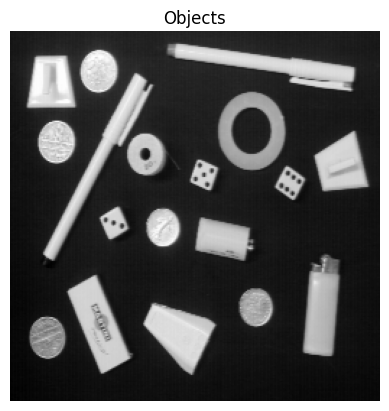

In [46]:
# leer imagen objects y pasar a int32
objects_image = cv2.imread(os.path.join(images_path, "OBJECTS.png"), cv2.IMREAD_GRAYSCALE).astype(np.int32)

# verificar que conserve los niveles de gris
print("Minimo:", np.min(objects_image))
print("Maximo:", np.max(objects_image))
print("Tipo de dato:", objects_image.dtype)

plt.imshow(objects_image, cmap="gray")
plt.title("Objects")
plt.axis("off")
plt.show()

### 1.3 Aplique un filtro de Sobel horizontal sobre la imagen (que corresponde al cálculo del gradiente de la imagen en la dirección X ). Visualice los resultados.

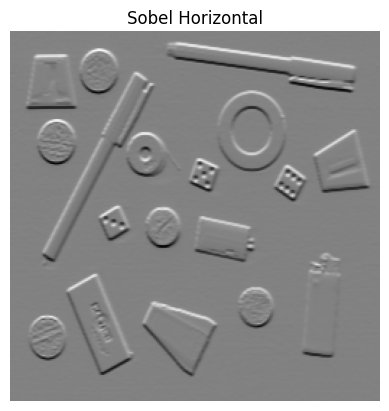

In [47]:
#Aplica el filtro Sobel horizontal
img_sh = sobel_h(objects_image)

#Visualiza el resultado
plt.imshow(img_sh, cmap="gray")
plt.title("Sobel Horizontal")
plt.axis("off")
plt.show()

### 1.4 Aplique un filtro de Sobel vertical sobre la imagen (que corresponde al cálculo del gradiente de la imagen en la dirección Y ). Visualice los resultados.

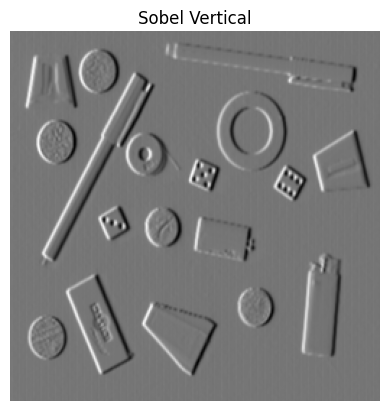

In [48]:
# aplicar el filtro Sobel vertical
img_sv = sobel_v(objects_image)

# visualizar el resultado
plt.imshow(img_sv, cmap="gray")
plt.title("Sobel Vertical")
plt.axis("off")
plt.show()

### 1.5 Calcule la norma (magnitud) del gradiente de acuerdo con la definición a partir de las dos imágenes resultantes anteriores. Visualice los resultados.

La magnitud del gradiente se puede calcular utilizando la fórmula:
$$\text{Magnitud} = \sqrt{(G_x)^2 + (G_y)^2}$$
donde $(G_x)$ es el resultado del filtro de Sobel horizontal y $(G_y)$ es el resultado del filtro de Sobel vertical. Visualice la imagen resultante utilizando una escala de grises para resaltar los bordes detectados.

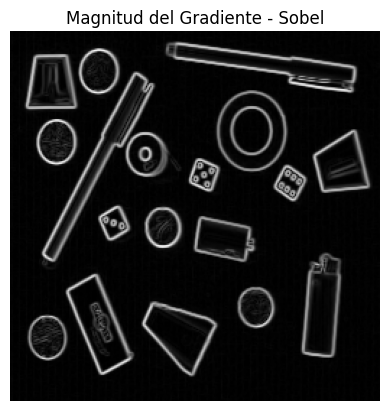

In [49]:
def calculate_gradient_magnitude(Gx, Gy):
    return np.sqrt(Gx**2 + Gy**2)

magnitud_sobel = calculate_gradient_magnitude(img_sh, img_sv)

# Visualizar la magnitud del gradiente
plt.imshow(magnitud_sobel, cmap="gray")
plt.title("Magnitud del Gradiente - Sobel")
plt.axis("off")
plt.show()

### 1.6 Describa cualitativamente cada una de estas tres imágenes: imagen del gradiente en X, imagen del gradiente en Y e imagen de la norma del gradiente.

Al aplicar el filtro de Sobel horizontal (gradiente en $x$), se resaltan los bordes verticales debido a los cambios de intensidad en la dirección horizontal. Esto se evidencia en el objeto circular de la esquina superior derecha, donde se observan trazos claros siguiendo el eje $x$. Por el contrario, el filtro de Sobel vertical (gradiente en $y$) enfatiza los bordes horizontales al detectar variaciones de intensidad en el eje vertical, revelando con claridad las partes superior e inferior de las figuras presentes en la escena, siendo esto claro al comparar el objeto circular del filtro horizontal con el vertical. 

La norma del gradiente, calculada mediante la raíz cuadrada de la suma de gradientes al cuadrado ($\sqrt{g_x^2 + g_y^2}$), integra los resultados para ofrecer una representación completa de los contornos. Esta combinación permite que los objetos, como el círculo mencionado, exhiban bordes definidos y prominentes en todas las direcciones, consolidando la información estructural obtenida por los filtros individuales en una sola imagen.

### 1.7 Aplique un filtro de Sobel sobre la imagen y visualice los resultados. Compare la imagen con la obtenido en el punto anterior.

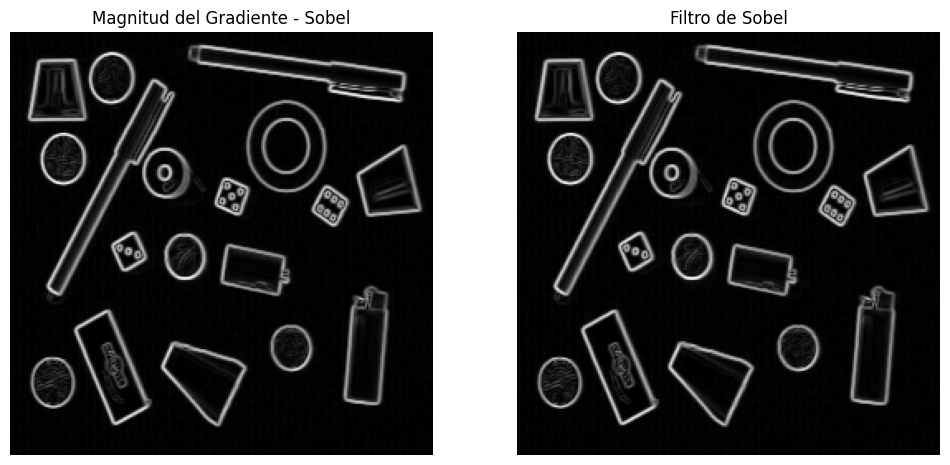

In [50]:
sobel_img = sobel(objects_image)

# Visualizar la imagen resultante del filtro de Sobel
plt.figure(figsize=(12, 10))
plt.subplot(1, 2, 1)
plt.imshow(magnitud_sobel, cmap="gray")
plt.title("Magnitud del Gradiente - Sobel")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(sobel_img, cmap="gray")
plt.title("Filtro de Sobel")
plt.axis("off")

plt.show()

A nivel visual, no se aprecian diferencias significativas entre la magnitud del gradiente calculada mediante la raíz de la suma de cuadrados ($\sqrt{g_x^2 + g_y^2}$) y la aproximación de Sobel basada en la suma de magnitudes absolutas ($∣g_x∣+∣g_y∣$), ya que ambos métodos logran resaltar los contornos de manera efectiva. No obstante, desde un punto de vista técnico, el uso de la raíz cuadrada garantiza que la intensidad del borde se mantenga constante independientemente de su dirección; por el contrario, la suma de magnitudes es una simplificación computacional que tiende a sobrestimar ligeramente el brillo en los bordes diagonales, aunque este efecto es prácticamente imperceptible a simple vista.


### 1.8 Aplique un filtro de Prewitt horizontal sobre la imagen (que corresponde al cálculo del gradiente de la imagen en la dirección X ). Visualice los resultados.

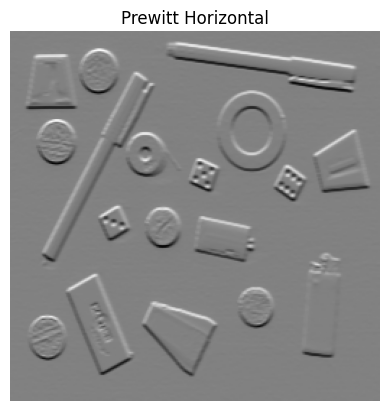

In [51]:
# prewitt horizontal
img_ph = prewitt_h(objects_image)

# visualizar el resultado
plt.imshow(img_ph, cmap="gray")
plt.title("Prewitt Horizontal")
plt.axis("off")
plt.show()

### 1.9 Aplique un filtro de Prewitt vertical sobre la imagen (que corresponde al cálculo del gradiente de la imagen en la dirección X ). Visualice los resultados.

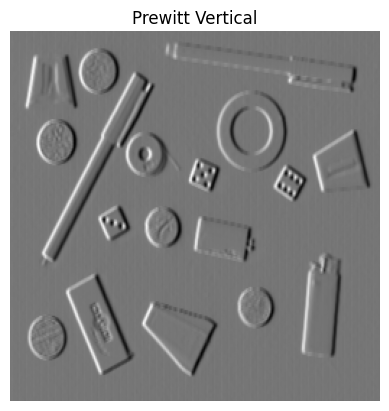

In [52]:
# prewitt vertical
img_pv = prewitt_v(objects_image)

# visualizar el resultado
plt.imshow(img_pv, cmap="gray")
plt.title("Prewitt Vertical")
plt.axis("off")
plt.show()

### 1.10 Calcule la norma (magnitud) del gradiente de acuerdo con la definición a partir de las dos imágenes resultantes anteriores. Visualice los resultados.

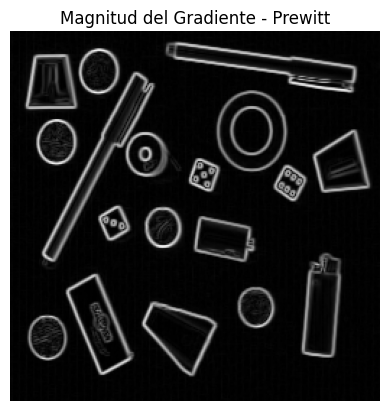

In [53]:
magnitud_prewitt = calculate_gradient_magnitude(img_ph, img_pv)

# Visualizar la magnitud del gradiente de Prewitt
plt.imshow(magnitud_prewitt, cmap="gray")
plt.title("Magnitud del Gradiente - Prewitt")
plt.axis("off")
plt.show()

### 1.11 Describa cualitativamente cada una de estas tres imágenes: imagen del gradiente en X, imagen del gradiente en Y e imagen de la norma del gradiente.

Las imágenes obtenidas tras aplicar los filtros de Prewitt horizontal y vertical presentan una detección de bordes muy similar a la del operador Sobel: el componente horizontal resalta los bordes verticales al detectar variaciones en el eje $x$, mientras que el componente vertical enfatiza los contornos horizontales. De hecho, la observación sobre el objeto circular de la esquina superior derecha se mantiene consistente en ambas representaciones. La norma del gradiente resultante consolida ambas direcciones en una representación completa de los contornos los objetos. Aunque ambos operadores son efectivos, el filtro de Sobel destaca teóricamente por otorgar un mayor peso a los píxeles centrales de su máscara, lo que le permite mitigar mejor el ruido y generar bordes ligeramente más definidos. No obstante, comparando los resultados visualmente, las diferencias entre ambos métodos son mínimas.

### 1.12 Aplique un filtro de Prewitt sobre la imagen y visualice los resultados. Compare la imagen con la obtenido en el punto anterior.

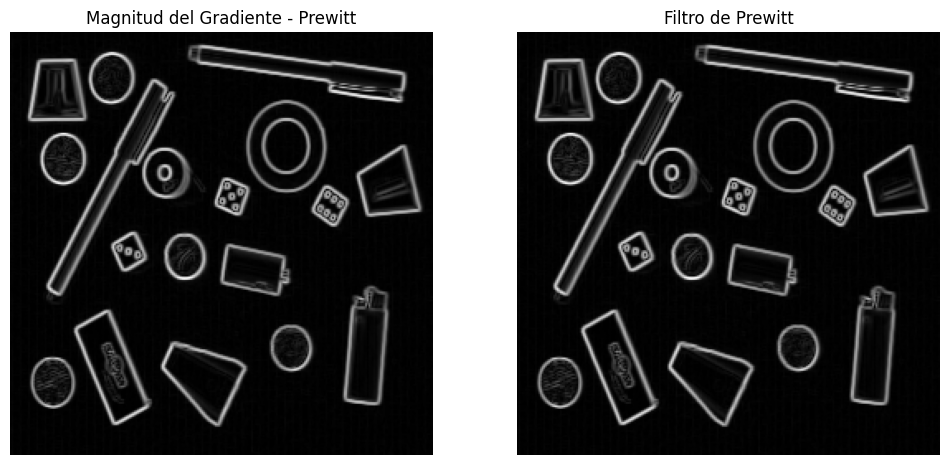

In [54]:
# filtro de Prewitt
prewitt_img = prewitt(objects_image)

# visualizar
plt.figure(figsize=(12, 10))
plt.subplot(1, 2, 1)
plt.imshow(magnitud_prewitt, cmap="gray")
plt.title("Magnitud del Gradiente - Prewitt")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(prewitt_img, cmap="gray")
plt.title("Filtro de Prewitt")
plt.axis("off")
plt.show()

La comparación entre los resultados obtenidos con la magnitud del gradiente calculada mediante la raíz de la suma de cuadrados ($\sqrt{g_x^2 + g_y^2}$) y la aproximación de Prewitt basada en la suma de magnitudes absolutas ($∣g_x∣+∣g_y∣$) arroja resultados muy similares. Al igual que sucede con el operador de Sobel, el cálculo mediante la raíz cuadrada ofrece una representación teórica más fiel de la intensidad del borde, mientras que la suma de magnitudes constituye una simplificación computacional que tiende a sobreestimar ligeramente los contornos diagonales. No obstante, a nivel visual, ambas metodologías logran resaltar las estructuras de la imagen con la misma eficacia, resultando en diferencias que son prácticamente imperceptibles a simple vista.

### 1.13 Sustraiga a la imagen de la norma de Prewitt, la imagen de la norma del gradiente calculada con el operador de Sobel.

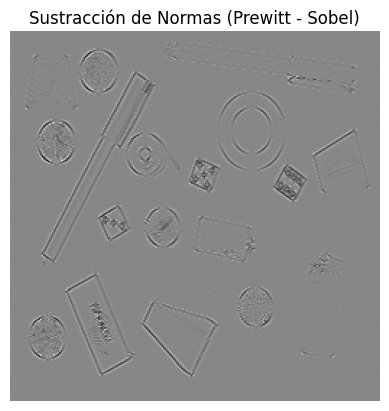

In [55]:
# aplicar la sustracción
subtraction = cv2.subtract(magnitud_prewitt, magnitud_sobel)

# visualizar el resultado
plt.imshow(subtraction, cmap="gray")
plt.title("Sustracción de Normas (Prewitt - Sobel)")
plt.axis("off")
plt.show()

### 1.14 ¿Qué diferencia visual hay entre el operador de Sobel y el de Prewitt?

Al sustraer la norma de Sobel a la de Prewitt, se obtiene una imagen que resalta las diferencias técnicas en la detección de bordes entre ambos operadores. En este resultado se observa una presencia principal de bordes diagonales, lo que sugiere que el filtro de Prewitt genera trazos más pronunciados en estas direcciones. Por el contrario, el filtro de Sobel, gracias a su ponderación central de 2, suaviza estas áreas y ofrece una detección más equilibrada y menos sensible a variaciones bruscas. Esta comparativa evidencia que Sobel proporciona una definición más nítida y controlada de los contornos, especialmente en orientaciones diagonales, mientras que Prewitt, al carecer de este efecto de suavizado, resulta más susceptible al ruido y a la generación de artefactos visuales en los bordes.

### 1.15 Para explicar esta diferencia, calcule numéricamente las respuestas del cálculo del gradiente en x, en y y de la norma del gradiente de cada uno de los dos filtros en los siguientes casos:

In [56]:
# creara las máscaras
frontera_hor_negro_blanco = np.array([[0, 0, 0],
                                    [0, 0, 0],
                                    [255, 255, 255]])

frontera_ver_negro_blanco = np.array([[0, 0, 255],
                                    [0, 0, 255],
                                    [0, 0, 255]])

frontera_oblicua_negro_blanco = np.array([[0, 0, 255],
                                          [0, 255, 255],
                                          [255, 255, 255]])

mascara_alejada_frontera_oblicua = np.array([[0, 0, 0],
                                             [0, 0, 0],
                                             [0, 0, 255]])

# crear los componentes en x y y de sobel y prewitt
gx_sobel = np.array([[-1, -2, -1],
                     [0, 0, 0],
                     [1, 2, 1]])

gy_sobel = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]])

gx_prewitt = np.array([[-1, -1, -1],
                       [0, 0, 0],
                       [1, 1, 1]])

gy_prewitt = np.array([[-1, 0, 1],
                       [-1, 0, 1],
                       [-1, 0, 1]])

# función para calcular cada valor
def compute_row(nombre, img):
    gx_s = np.sum(img * gx_sobel)
    gy_s = np.sum(img * gy_sobel)
    n_s  = calculate_gradient_magnitude(gx_s, gy_s)

    gx_p = np.sum(img * gx_prewitt)
    gy_p = np.sum(img * gy_prewitt)
    n_p  = calculate_gradient_magnitude(gx_p, gy_p)

    return {
        "Caso": nombre,
        "Sobel_Gx": gx_s,
        "Sobel_Gy": gy_s,
        "Sobel_Norma": n_s,
        "Prewitt_Gx": gx_p,
        "Prewitt_Gy": gy_p,
        "Prewitt_Norma": n_p
    }

rows = []
rows.append(compute_row("Frontera horizontal", frontera_hor_negro_blanco))
rows.append(compute_row("Frontera vertical", frontera_ver_negro_blanco))
rows.append(compute_row("Frontera oblicua", frontera_oblicua_negro_blanco))
rows.append(compute_row("Máscara alejada de frontera oblicua", mascara_alejada_frontera_oblicua))

df = pd.DataFrame(rows)
df.head()


,Caso,Sobel_Gx,Sobel_Gy,Sobel_Norma,Prewitt_Gx,Prewitt_Gy,Prewitt_Norma
0,Frontera horizontal,1020,0,1020.000000,765,0,765.000000
1,Frontera vertical,0,1020,1020.000000,0,765,765.000000
2,Frontera oblicua,765,765,1081.873375,510,510,721.248917
3,Máscara alejada de frontera oblicua,255,255,360.624458,255,255,360.624458


Los resultados numéricos demuestran que, en fronteras estrictamente horizontales o verticales, ambos filtros responden con la misma intensidad al cambio de brillo, aunque el operador de Sobel genera valores de magnitud más elevados debido a su ponderación central de 2. La diferencia clave se hace evidente en la frontera oblicua, donde Sobel alcanza una norma de 1081.87 frente a los 721.25 de Prewitt. Este incremento (del 0.5, pues 765/510 = 1.5) indica que Sobel es significativamente más sensible al detectar bordes diagonales. Finalmente, en el caso de la máscara alejada, ambos filtros arrojan el mismo valor (360.62), lo que evidencia que cuando el borde no coincide con el centro de la máscara, el peso adicional de Sobel no entra en juego, resultando en una respuesta idéntica a la de Prewitt para variaciones periféricas.

---

## 2. Filtro de Canny

### 2.1 Cree una nueva sección en su notebook.

### 2.2 Cargue y visualice la imagen rondelle.png. Aplique el operador de Sobel y describa el resultado (puede efectuar una calibración del histograma de la imagen obtenida para visualizar mejor el resultado).

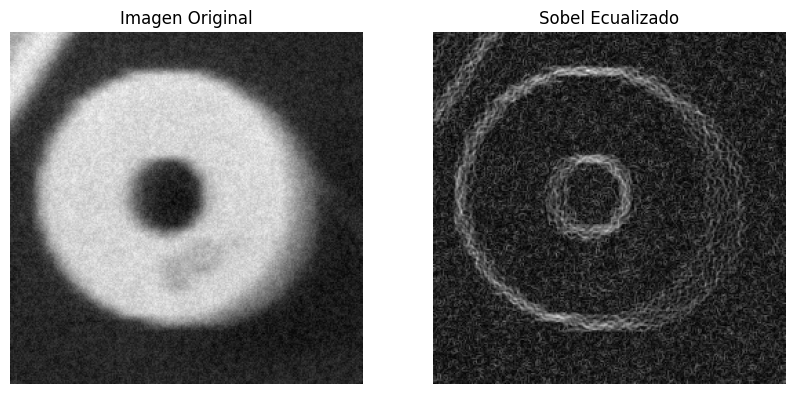

In [57]:
# carga de la imagen
rondelle_image = cv2.imread(images_path+"RONDELLE.png", cv2.IMREAD_GRAYSCALE)

# aplicar operador de Sobel
rondelle_sobel = sobel(rondelle_image)

# ecualizacion
equalized = exposure.rescale_intensity(rondelle_sobel, in_range=(rondelle_sobel.min(), rondelle_sobel.max()), out_range=(0, 255))

# visualizaciones
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(rondelle_image, cmap='gray')
plt.axis('off')
plt.title('Imagen Original')
plt.subplot(1, 2, 2)
plt.imshow(equalized, cmap='gray')
plt.axis('off')
plt.title('Sobel Ecualizado')
plt.show()


La imagen de RONDELLE presenta una cantidad significativa de ruido granulado que dificulta la definición de sus contornos. Al aplicar el operador de Sobel, este ruido provoca la aparición de múltiples bordes falsos y texturas irregulares, ya que el filtro resalta indiscriminadamente cualquier variación de intensidad, sea esta parte del objeto o ruido aleatorio. Como resultado, la detección de bordes se ve altamente afectada, dificultando la identificación precisa de la silueta principal y evidenciando la necesidad de un preprocesamiento de suavizado para filtrar el ruido antes de la detección de bordes.


### 2.3 Ahora aplique sobre la imagen original el operador de Canny, con los siguientes valores de parámetros y visualice la imagen resultado y descríbala.

- Desviación estándar = 10. Esto indica que se va a filtrar considerablemente la imagen original.

- Umbral inferior (low_threshold) = 0

- Umbral superior (high_threshold) = 1. Este umbral permite eliminar la mayoría de falsas detecciones de pequeña amplitud del gradiente.

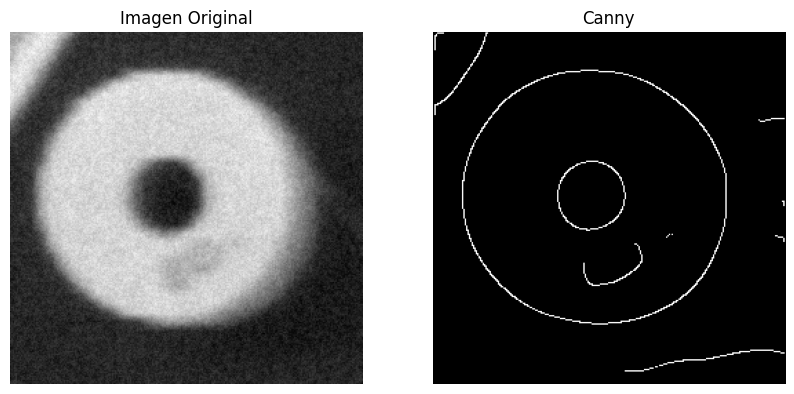

In [58]:
# aplicar el operador sobre la imagen
canny_rondelle = canny(rondelle_image, sigma=10, low_threshold=0, high_threshold=1)

# visualizar original y canny
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(rondelle_image, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(canny_rondelle, cmap='gray')
plt.title('Canny')
plt.axis('off')
plt.show()

El algoritmo de Canny implementa una secuencia de procesos que incluye el suavizado mediante un filtro gaussiano, el cálculo del gradiente, la supresión de no máximos, la umbralización por histéresis y la conexión de contornos. Al aplicarlo sobre la imagen de RONDELLE con una desviación estándar de 10, se logra mitigar el ruido granulado de fondo, permitiendo que los bordes del objeto principal se detecten de forma continua y bien definida. No obstante, todavía persisten artefactos o líneas adicionales que no pertenecen al contorno real. Esto puede deberse a que el ruido original era tan intenso que algunas de sus variaciones, tras el suavizado, aún conservan una magnitud de gradiente lo suficientemente alta como para superar el umbral y ser clasificadas erróneamente como bordes legítimos.

### 2.4 Disminuya la desviación a estándar a 5 (en X y en Y ), visualice la imagen resultado y explique lo que sucede.

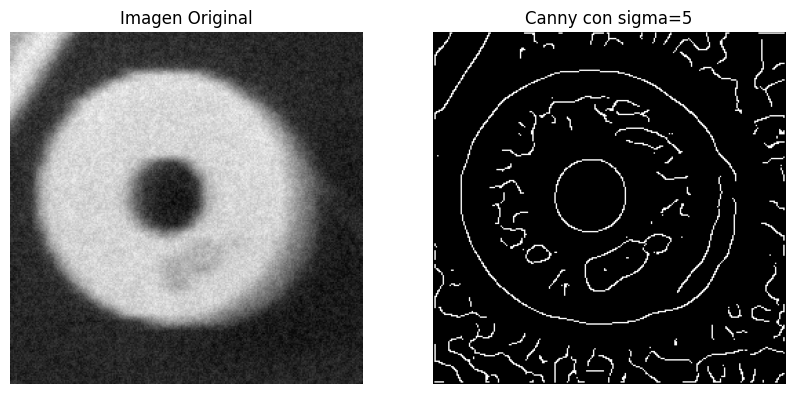

In [59]:
# disminuir la desviación estándar a 5
canny_rondelle_sigma5 = canny(rondelle_image, sigma=5, low_threshold=0, high_threshold=1)

# visualizar original y canny con sigma 5
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(rondelle_image, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(canny_rondelle_sigma5, cmap='gray')
plt.title('Canny con sigma=5')
plt.axis('off')
plt.show()

Al reducir la desviación estándar a 5, el filtro gaussiano aplicado en el proceso de Canny se vuelve menos agresivo, lo que resulta en una menor suavización de la imagen original. Como consecuencia, el ruido presente en la imagen de RONDELLE no se filtra completamente, provocando que el algoritmo detecte una mayor cantidad de bordes falsos y artefactos. Se observa además una desconexión en los bordes del objeto principal, ya que el ruido interfiere con la continuidad de los contornos. 

### 2.5 Aumente el umbral superior a 5 con los valores de desviación estándar del punto 3 y 4. visualice y compare los resultados con las imágenes obtenidas en el punto anterior.

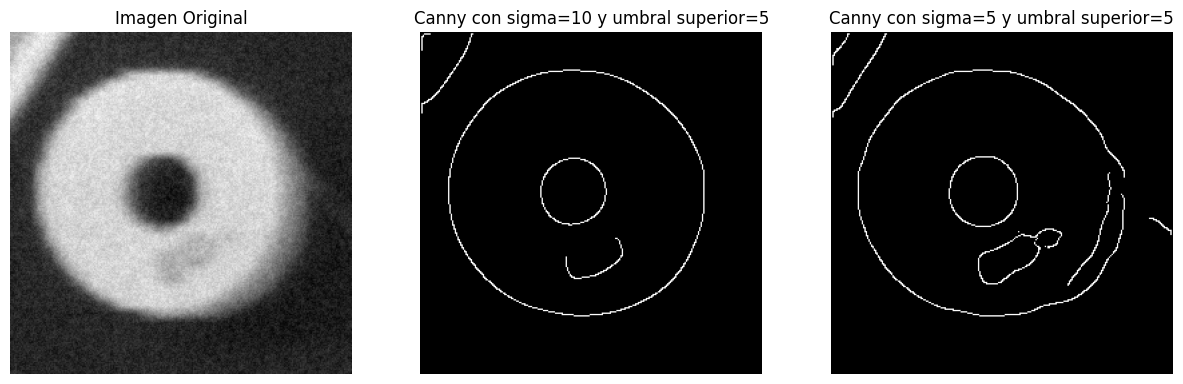

In [60]:
# aplicar el operador sobre la imagen
canny_rondelle_sup5_sd10 = canny(rondelle_image, sigma=10, low_threshold=0, high_threshold=5)
canny_rondelle_sup5_sd5 = canny(rondelle_image, sigma=5, low_threshold=0, high_threshold=5)

# visualizar original y canny
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(rondelle_image, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(canny_rondelle_sup5_sd10, cmap='gray')
plt.title('Canny con sigma=10 y umbral superior=5')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(canny_rondelle_sup5_sd5, cmap='gray')
plt.title('Canny con sigma=5 y umbral superior=5')
plt.axis('off')
plt.show()

Al aumentar el umbral superior a 5, se establece un criterio de filtrado mucho más restrictivo para la validación de píxeles como bordes definitivos. En ambos casos (desviación estándar de 10 y 5), esto produce una reducción drástica de falsos positivos, ya que el algoritmo solo conserva aquellas estructuras cuya magnitud de gradiente es alta.

En la imagen con $\sigma = 10$, el preprocesamiento eliminó eficazmente el ruido de alta frecuencia, permitiendo que el umbral superior limpie casi todos los artefactos y deje los contornos principales bien definidos. Por el contrario, en la imagen con $\sigma = 5$, el suavizado fue insuficiente para mitigar el ruido original; por lo tanto, al aplicar un umbral tan alto, los bordes reales se fragmentan y pierden definición, ya que el algoritmo no logra distinguir consistentemente entre el ruido y los contornos del objeto principal. En conclusión, aunque un umbral superior elevado purifica la detección, su éxito depende críticamente de un nivel de suavizado que garantice una relación señal-ruido adecuada.

## 3. Laplaciano

### 3.1 Cree una nueva sección en su notebook.
### 3.2 Cargue y visualice la imagen spot.png.

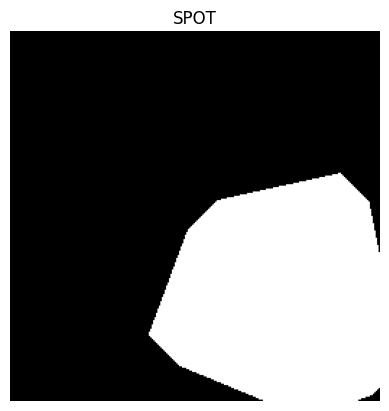

In [72]:
spot_image = cv2.imread(os.path.join(images_path, "SPOT.png"), cv2.IMREAD_GRAYSCALE)

plt.imshow(spot_image, vmax=255, vmin=0, cmap="gray")
plt.title("SPOT")
plt.axis("off")
plt.show()

### 3.3 Antes de aplicar el filtro Laplaciano es necesario modificar el tipo de la imagen para que esta pueda contener niveles de gris negativos. Convierta la imagen a tipo Int16.

In [64]:
spot_image = spot_image.astype(np.int16)

### 3.4 Aplique un filtro Laplaciano. Visualice el resultado (puede efectuar una calibración del histograma -entre 0 y 255- de la imagen obtenida para visualizar mejor los detalles de la imagen del Laplaciano).

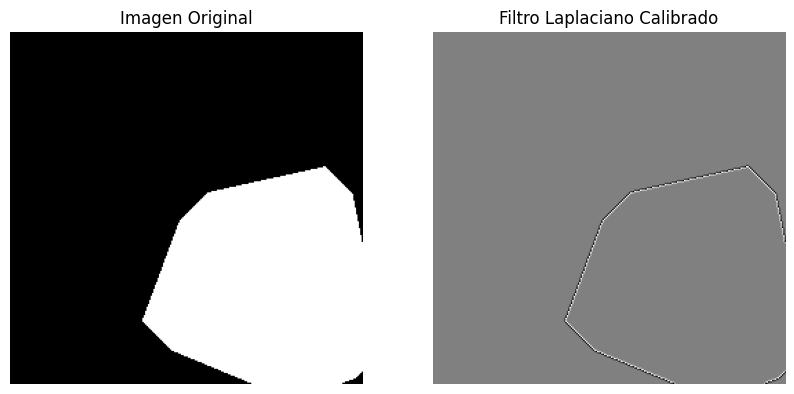

In [70]:
# aplicar el filtro Laplaciano
spot_laplace = laplace(spot_image, ksize=3) #ksize es el tamaño del kernel

# calibración del histograma
spot_laplace_calibrado = exposure.rescale_intensity(spot_laplace, in_range=(spot_laplace.min(), spot_laplace.max()), out_range=(0, 255))

# visualizar el resultado
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(spot_image, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(spot_laplace_calibrado, cmap='gray')
plt.title('Filtro Laplaciano Calibrado')
plt.axis('off')
plt.show()

### 3.5 ¿Cómo es la respuesta del Laplaciano en las regiones homogéneas de la imagen y en los contornos? ¿A qué se debe este resultado?

El filtro Laplaciano calcula la segunda derivada de la imagen para detectar cambios abruptos de intensidad. En las regiones homogéneas, al no haber cambios significativos de tonalidad, el filtro responde con valores de cero. En la imagen, esto se aprecia como un gris uniforme, lo que indica la ausencia de bordes debido a que el operador solo reacciona cuando detecta una variación en la tasa de cambio de la luminosidad.

En contraste, en los contornos, se produce una transición brusca donde la intensidad cambia de dirección, lo que genera tonos negros y blancos dependiendo de si el cambio es de negro a blanco o viceversa. Este resultado se debe a que el filtro resalta los puntos de inflexión de la intensidad, permitiendo que la imagen resultante muestre claramente el borde de la figura SPOT como el punto exacto de transición entre estos dos extremos.

### 3.6 Aplique un filtro Gaussiano con varianza en 0 a la imagen. Visualice el resultado.

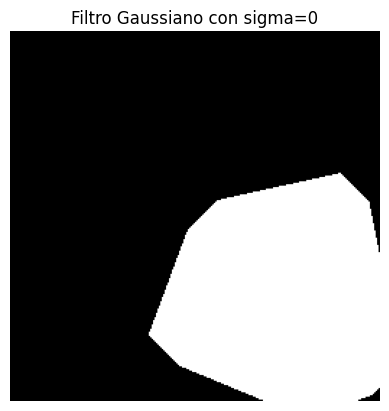

In [78]:
# aplicar un filtro Gaussiano con varianza en 0
spot_gaussian_filter = gaussian(spot_image, sigma=0, preserve_range=True) #si preserve range es False, la imagen se noramliza

plt.imshow(spot_gaussian_filter, cmap='gray')
plt.title('Filtro Gaussiano con sigma=0')
plt.axis('off')
plt.show()

### 3.7 Aplique sobre el resutlado del paso anterior un filtro Laplaciano. Visualice el resultado (puede efectuar una calibración del histograma -entre 0 y 255- de la imagen obtenida para visualizar mejor los detalles de la imagen del Laplaciano). ¿Cómo es la respuesta de este LoG con respecto al Laplaciano sin filtrado previo del ejercicio anterior? ¿A qué se debe este resultado?

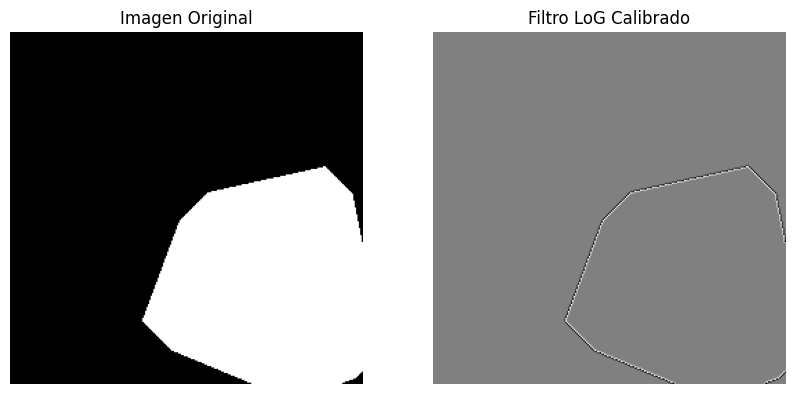

In [79]:
# aplicar el filtro Laplaciano
spot_log = laplace(spot_gaussian_filter, ksize=3) #ksize es el tamaño del kernel

# calibración del histograma
spot_log_calibrado = exposure.rescale_intensity(spot_log, in_range=(spot_log.min(), spot_log.max()), out_range=(0, 255))

# visualizar el resultado
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(spot_image, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(spot_log_calibrado, cmap='gray')
plt.title('Filtro LoG Calibrado')
plt.axis('off')
plt.show()

In [81]:
# comprobar cambios entre imagen original y con filtro gaussiano con varianza en 0
np.all(spot_image == spot_gaussian_filter)

np.True_

La finalidad de aplicar un filtro Gaussiano antes de utilizar el Laplaciano es suavizar la imagen para reducir el ruido, el cual suele manifestarse como variaciones de alta frecuencia. Debido a que el Laplaciano se basa en segundas derivadas, es extremadamente sensible a estas fluctuaciones; sin el filtrado previo, el ruido se amplificaría, generando múltiples bordes falsos y dificultando la detección de los contornos reales.

En este caso particular, al aplicar un filtro Gaussiano con varianza 0, el suavizado no produce ningún efecto, por lo que la imagen resultante es idéntica a la original, como se puede comprobar en el bloque de código previo. En consecuencia, la respuesta del operador Laplaciano en este ejercicio es igual a la obtenida anteriormente, ya que se están procesando los mismos valores que los de la imagen original.

### 3.8 Repita los pasos 1 y 2, pero cambiando a 1 el valor de la varianza en el filtro gaussiano. ¿Cómo es la respuesta de este LoG con respecto al Laplaciano sin filtrado previo del ejercicio anterior? ¿A qué se debe este resultado?